<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap04/4_3_Deep_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 4.3 Deep neural networks**

This notebook investigates converting neural networks to matrix form.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
import matplotlib as mpl
mpl.rcParams['font.sans-serif']=['Microsoft YaHei','SimHei','DejaVu Sans']
mpl.rcParams['axes.unicode_minus']=False
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [4]:
# # Plot the shallow neural network.  We'll assume input in is range [-1,1] and output [-1,1]
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Input'); ax.set_ylabel('Output')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

Let's define a network.  We'll just consider the inputs and outputs over the range [-1,1].

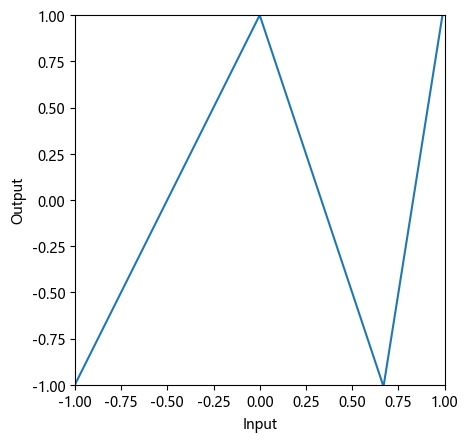

In [5]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define a range of input values
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# We run the neural network for each of these input values
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# And then plot it
plot_neural(n1_in, n1_out)
# 独立保存逐神经元 reference，后续矩阵实现不会覆盖它。
scalar_reference = n1_out.copy()

Now we'll define the same neural network, but this time, we will  use matrix form as in equation 4.15.  When you get this right, it will draw the same plot as above.

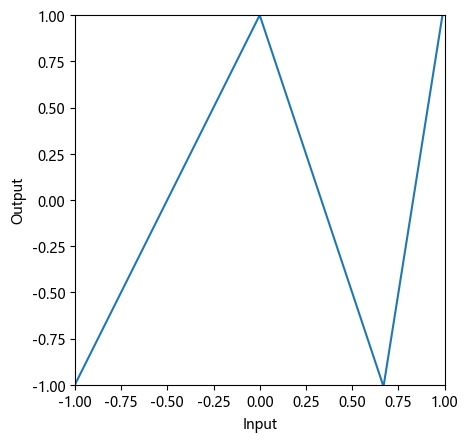

单浅层 scalar↔matrix: max_abs= 2.220446049250313e-16 MSE= 1.6023737137301803e-33 allclose=True


In [6]:
# 先完整填充 beta/Omega，再进行矩阵前向、绘图和等价性断言。
beta_0 = np.zeros((3,1)); Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1)); Omega_1 = np.zeros((1,3))

beta_0[:,0]=[n1_theta_10,n1_theta_20,n1_theta_30]
Omega_0[:,0]=[n1_theta_11,n1_theta_21,n1_theta_31]
beta_1[0,0]=n1_phi_0
Omega_1[0,:]=[n1_phi_1,n1_phi_2,n1_phi_3]
n_data=n1_in.size; n1_in_mat=np.reshape(n1_in,(1,n_data))
h1=ReLU(beta_0+Omega_0@n1_in_mat)
matrix_shallow=beta_1+Omega_1@h1
plot_neural(n1_in, matrix_shallow)
np.testing.assert_allclose(matrix_shallow,scalar_reference,atol=1e-10,rtol=1e-10)
print("单浅层 scalar↔matrix: max_abs=",np.max(np.abs(matrix_shallow-scalar_reference)),
      "MSE=",np.mean((matrix_shallow-scalar_reference)**2),"allclose=True")

Now we'll feed the output of the first network into the second one.

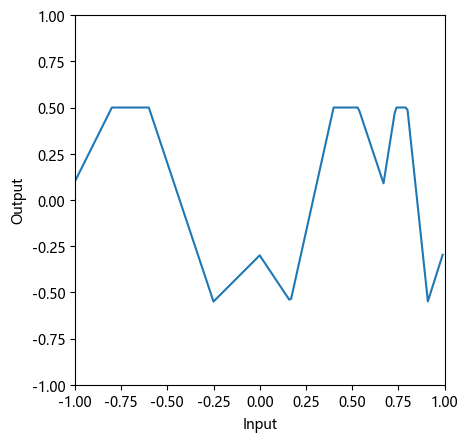

In [7]:
# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define a range of input values
n2_in = np.arange(-1,1,0.01)

# We run the second neural network on the output of the first network
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# And then plot it
plot_neural(n1_in, n2_out)

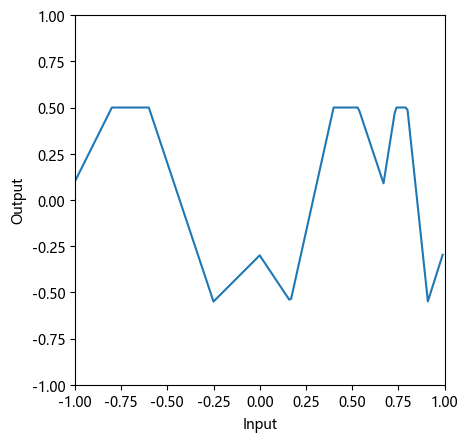

两个浅层矩阵串联 max_abs= 3.3306690738754696e-16 MSE= 1.7872629883913547e-33 allclose=True
合并两隐藏层矩阵 max_abs= 3.3306690738754696e-16 MSE= 7.719127217104041e-33 allclose=True
beta_0=
 [[ 0.  ]
 [ 0.  ]
 [-0.67]] 
Omega_0=
 [[-1.]
 [ 1.]
 [ 1.]] 
beta_1=
 [[-1.6]
 [ 1.2]
 [ 0.5]] 
Omega_1=
 [[ 2.   3.  -9.3]
 [-2.  -3.   9.3]
 [-2.  -3.   9.3]] 
beta_2=
 [[0.5]] 
Omega_2=
 [[-1.  -1.5  2. ]]


In [8]:
# 先完整填充两个网络合并后的 beta/Omega，再进行前向、绘图和断言。
beta_0 = np.zeros((3,1)); Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((3,1)); Omega_1 = np.zeros((3,3))
beta_2 = np.zeros((1,1)); Omega_2 = np.zeros((1,3))

beta_0[:,0]=[n1_theta_10,n1_theta_20,n1_theta_30]
Omega_0[:,0]=[n1_theta_11,n1_theta_21,n1_theta_31]
n_data=n1_in.size; n1_in_mat=np.reshape(n1_in,(1,n_data))
w=np.array([[n2_theta_11],[n2_theta_21],[n2_theta_31]],dtype=float)
v=np.array([[n1_phi_1,n1_phi_2,n1_phi_3]],dtype=float)
b=np.array([[n2_theta_10],[n2_theta_20],[n2_theta_30]],dtype=float)
c=float(n1_phi_0)
beta_1[:]=b+w*c
Omega_1[:]=w@v
beta_2[0,0]=n2_phi_0
Omega_2[0,:]=[n2_phi_1,n2_phi_2,n2_phi_3]
h1=ReLU(beta_0+Omega_0@n1_in_mat);h2=ReLU(beta_1+Omega_1@h1);combined=beta_2+Omega_2@h2
plot_neural(n1_in, combined)
first_matrix=np.array([[n1_phi_0]])+v@h1
b2=np.array([[n2_theta_10],[n2_theta_20],[n2_theta_30]])
h2_serial=ReLU(b2+w@first_matrix);serial_matrix=np.array([[n2_phi_0]])+Omega_2@h2_serial
scalar_first,*_=shallow_1_1_3(n1_in_mat,ReLU,n1_phi_0,n1_phi_1,n1_phi_2,n1_phi_3,n1_theta_10,n1_theta_11,n1_theta_20,n1_theta_21,n1_theta_30,n1_theta_31)
scalar_serial,*_=shallow_1_1_3(scalar_first,ReLU,n2_phi_0,n2_phi_1,n2_phi_2,n2_phi_3,n2_theta_10,n2_theta_11,n2_theta_20,n2_theta_21,n2_theta_30,n2_theta_31)
for label,out in (("两个浅层矩阵串联",serial_matrix),("合并两隐藏层矩阵",combined)):
    np.testing.assert_allclose(out,scalar_serial,atol=1e-10,rtol=1e-10)
    print(label,"max_abs=",np.max(np.abs(out-scalar_serial)),"MSE=",np.mean((out-scalar_serial)**2),"allclose=True")
print("beta_0=\n",beta_0,"\nOmega_0=\n",Omega_0,"\nbeta_1=\n",beta_1,"\nOmega_1=\n",Omega_1,"\nbeta_2=\n",beta_2,"\nOmega_2=\n",Omega_2)

Now let's make a deep network with 3 hidden layers.  It will have $D_i=4$ inputs, $D_1=5$ neurons  in the first layer, $D_2=2$ neurons in the second layer and $D_3=4$ neurons in the third layer, and $D_o = 1$ output.  Consult figure 4.6 and equations 4.15 for guidance.

In [9]:
# 指定结构 4→5→2→4→1、n_data=4、随机正态初始化和可复现种子。
D_i,D_1,D_2,D_3,D_o=4,5,2,4,1
rng=np.random.default_rng(20260919);n_data=4;x=rng.normal(size=(D_i,n_data))
beta_0=rng.normal(size=(D_1,1));Omega_0=rng.normal(size=(D_1,D_i))
beta_1=rng.normal(size=(D_2,1));Omega_1=rng.normal(size=(D_2,D_1))
beta_2=rng.normal(size=(D_3,1));Omega_2=rng.normal(size=(D_3,D_2))
beta_3=rng.normal(size=(D_o,1));Omega_3=rng.normal(size=(D_o,D_3))
def deep_forward(x):
    h1=ReLU(beta_0+Omega_0@x);h2=ReLU(beta_1+Omega_1@h1);h3=ReLU(beta_2+Omega_2@h2);return h1,h2,h3,beta_3+Omega_3@h3
h1,h2,h3,y=deep_forward(x)
expected={"x":(4,4),"h1":(5,4),"h2":(2,4),"h3":(4,4),"y":(1,4)}
actual={"x":x.shape,"h1":h1.shape,"h2":h2.shape,"h3":h3.shape,"y":y.shape};assert actual==expected
layer_params=[Omega_0.size+beta_0.size,Omega_1.size+beta_1.size,Omega_2.size+beta_2.size,Omega_3.size+beta_3.size]
assert layer_params==[25,12,12,5] and sum(layer_params)==54
for batch in (1,4,7):
    xx=rng.normal(size=(4,batch));yb=deep_forward(xx)[-1]
    yl=np.hstack([deep_forward(xx[:,i:i+1])[-1] for i in range(batch)])
    np.testing.assert_allclose(yb,yl,atol=1e-12,rtol=1e-12);assert np.isfinite(yb).all()
    print(f"batch={batch}: shape={yb.shape}, loop max_abs={np.max(np.abs(yb-yl))}")
print("逐层参数量",layer_params,"总参数量",sum(layer_params),"；完整 shape 断言通过。")

batch=1: shape=(1, 1), loop max_abs=0.0
batch=4: shape=(1, 4), loop max_abs=7.771561172376096e-16
batch=7: shape=(1, 7), loop max_abs=3.552713678800501e-15
逐层参数量 [25, 12, 12, 5] 总参数量 54 ；完整 shape 断言通过。


## 参数效率解释（增强）

每个 `1→3→1` 浅层块有 10 个存储参数，两个独立块串联为 20 个。把它展开为一般 `1→3→3→1` 密集数组共有 22 个数值槽位，但中间 `3×3` 权重是外积 `w@v`，不是 9 个独立自由参数。

对 N 个 f 后接 g：独立存储时为 `10(N+1)`；若程序真正共享同一份 f 权重，则唯一存储参数仍为 20，但调用次数为 `N+1`。线性区域数只反映表达复杂度的一面，不保证训练更好，也不表示每个区域可独立控制。